In [1]:
# Import necessary libraries
import os, mne, re, csv, numpy as np, matplotlib.pyplot as plt
from glob import glob
from mne.channels import make_standard_montage
from mne.time_frequency import tfr_morlet
from eeg_function import drop_trials, single_trial_normalisation
# Set the derivatives directory path
root_derivatives = 'C:/Users/mfbpe/Desktop/DATA/2025_Valuation/derivatives/'

# Change the current working directory to the derivatives directory
os.chdir(root_derivatives)

all_files_path = sorted(glob(f"*raw.fif"), key=len)

In [2]:

event_id_stim = { 
    'stim/motiv/extr':11,'stim/motiv/hard':12,'stim/motiv/easy':13,'stim/amotiv/extr':14,'stim/amotiv/hard':15,'stim/amotiv/easy':16
}


part = all_files_path[0]
raw = mne.io.read_raw_fif(part, preload=True)

events = mne.find_events(raw, shortest_event=1)            

epochs= mne.Epochs(raw, events,baseline = (-.3, -.1), event_id=event_id_stim, picks='eeg',
        tmin=-1.6, tmax=2,preload=True, detrend=None, on_missing='ignore')





Opening raw data file sub-1_raw.fif...
    Range : 0 ... 1927679 =      0.000 ...  3764.998 secs
Ready.
Reading 0 ... 1927679  =      0.000 ...  3764.998 secs...
Finding events on: Status
2016 events found on stim channel Status
Event IDs: [ 1  2  3  4  5  6 11 12 13 14 15 16 21 22 23 24 25 26 31 32 33 34 35 36
 41 42 43 44 45 46 51 52 53 54 55 56]
Not setting metadata
336 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 336 events and 1844 original time points ...
0 bad epochs dropped


In [3]:
raw

<Raw | sub-1_raw.fif, 73 x 1927680 (3765.0 s), ~1.05 GiB, data loaded>

In [4]:
events

array([[  47338,       0,       5],
       [  47855,       0,      15],
       [  50161,       0,      25],
       ...,
       [1918385,       0,      31],
       [1918642,       0,      41],
       [1919664,       0,      51]], shape=(2016, 3))

In [5]:
epochs

<Epochs | 336 events (all good), -1.6 – 2 s (baseline -0.3 – -0.1 s), ~302.6 MiB, data loaded,
 'stim/motiv/extr': 56
 'stim/motiv/hard': 56
 'stim/motiv/easy': 56
 'stim/amotiv/extr': 56
 'stim/amotiv/hard': 56
 'stim/amotiv/easy': 56>

# Design of the Task

![title](design.png)

# Incentive ERP
Glazer, J. E., Kelley, N. J., Pornpattananangkul, N., Mittal, V. A., & Nusslock, R. (2018). Beyond the FRN: Broadening the time-course of EEG and ERP components implicated in reward processing. International Journal of Psychophysiology, Reward and Feedback Processing: State of the Field, Best Practices and Future Directions, 132, 184–202. https://doi.org/10.1016/j.ijpsycho.2018.02.002


![title](incentives.png)

# Difficulty - Conflict ERP / TFR
Cavanagh, J. F., & Frank, M. J. (2014). Frontal theta as a mechanism for cognitive control. Trends in Cognitive Sciences, 18(8), 414–421. https://doi.org/10.1016/j.tics.2014.04.012

![title](Difficulty.png)

Need more than one channel to make topography for eeg. Disabling interactivity.


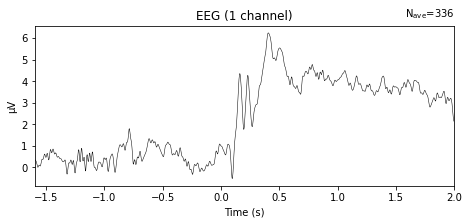

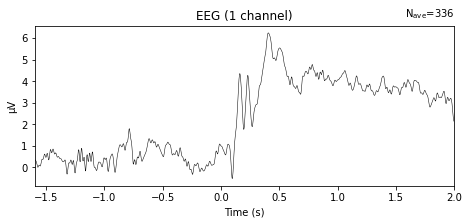

In [6]:
epochs.average().plot(picks="Pz")

Applying baseline correction (mode: mean)
Need more than one channel to make topography for eeg. Disabling interactivity.


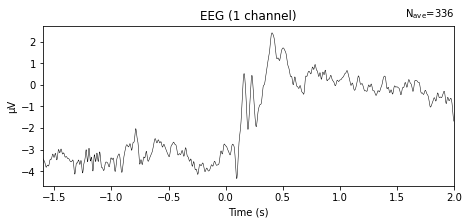

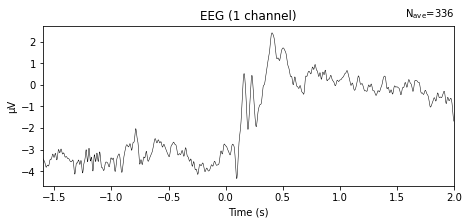

In [7]:
epochs.average().apply_baseline((1,1.5)).plot(picks="Pz")

In [52]:

sphere = mne.make_sphere_model('auto', 'auto', epochs.info)
src = mne.setup_volume_source_space(sphere=sphere)
forward = mne.make_forward_solution(epochs.info, trans=None, src=src, bem=sphere)



Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 -0.0 40.1 mm
Origin device coordinates:    -0.0 -0.0 40.1 mm

Equiv. model fitting -> RV = 0.00348862 %%
mu1 = 0.944723    lambda1 = 0.137154
mu2 = 0.66746    lambda2 = 0.683797
mu3 = -0.267046    lambda3 = -0.0105814
Set up EEG sphere model with scalp radius    95.0 mm

Sphere                : origin at (-0.0 -0.0 40.1) mm
              radius  : 85.5 mm
grid                  : 5.0 mm
mindist               : 5.0 mm

Setting up the sphere...
Surface CM = (  -0.0   -0.0   40.1) mm
Surface fits inside a sphere with radius   85.5 mm
Surface extent:
    x =  -85.5 ...   85.5 mm
    y =  -85.5 ...   85.5 mm
    z =  -45.4 ...  125.6 mm
Grid extent:
    x =  -90.0 ...   90.0 mm
    y =  -90.0 ...   90.0 mm
    z =  -50.0 ...  130.0 mm
50653 sources before omitting any.
20895 sources after omitting infeasible sources not within 0.0 - 85.5 mm.
17437 sources remaining after excluding the sources outside the surface and les

In [69]:

epochs.set_eeg_reference('REST', forward=forward)
# epochs.set_eeg_reference("average")
# epochs.set_eeg_reference(["T7","T8"])

    

EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    64 out of 64 channels remain after picking


<Epochs | 336 events (all good), -1.6 – 2 s (baseline -0.3 – -0.1 s), ~302.6 MiB, data loaded,
 'stim/motiv/extr': 56
 'stim/motiv/hard': 56
 'stim/motiv/easy': 56
 'stim/amotiv/extr': 56
 'stim/amotiv/hard': 56
 'stim/amotiv/easy': 56>

Need more than one channel to make topography for eeg. Disabling interactivity.


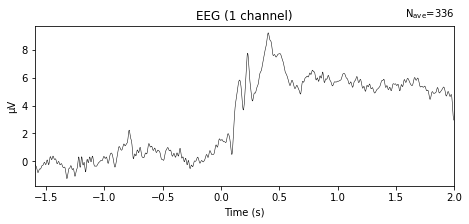

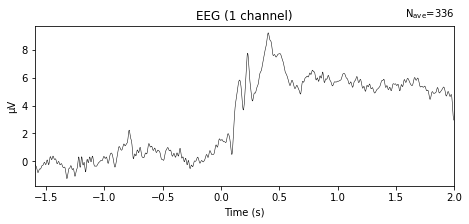

In [70]:
epochs.average().plot(picks="Pz")

In [71]:
chs_index = [i for i,x in enumerate(epochs.info['ch_names']) if x in ['FCz','Pz']]
epochs_comb = mne.channels.combine_channels(epochs, dict(Avg=chs_index)) # reject artifact on the combination of channels of interest
epochs_comb

Not setting metadata
336 matching events found
Applying baseline correction (mode: mean)
0 projection items activated


<EpochsArray | 336 events (all good), -1.6 – 2 s (baseline -0.3 – -0.1 s), ~4.7 MiB, data loaded,
 'stim/motiv/extr': 56
 'stim/motiv/hard': 56
 'stim/motiv/easy': 56
 'stim/amotiv/extr': 56
 'stim/amotiv/hard': 56
 'stim/amotiv/easy': 56>

In [72]:

epochs_cleaned,list_ti, reject_mean, reject_peak, reject_slope = drop_trials(epochs_comb, do_mean=1, do_peak=1, do_slope=1, T1=-.3,T2=.5, chs='all')  



Dropped 65 epochs: 10, 11, 17, 18, 23, 39, 40, 44, 49, 50, 52, 53, 54, 57, 63, 68, 70, 81, 83, 85, 87, 88, 95, 98, 102, 107, 109, 116, 121, 122, 123, 127, 128, 130, 141, 145, 146, 147, 159, 160, 161, 165, 176, 185, 212, 218, 222, 229, 230, 252, 254, 264, 270, 274, 276, 285, 290, 302, 309, 312, 313, 316, 320, 330, 331


In [73]:
epochs_cleaned

<EpochsArray | 271 events (all good), -1.6 – 2 s (baseline -0.3 – -0.1 s), ~3.8 MiB, data loaded,
 'stim/motiv/extr': 44
 'stim/motiv/hard': 43
 'stim/motiv/easy': 50
 'stim/amotiv/extr': 45
 'stim/amotiv/hard': 45
 'stim/amotiv/easy': 44>

In [74]:
list_ti

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1.,
       0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0.,
       1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1.,
       0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 0., 1., 1., 1.

In [75]:
reject_peak, reject_mean, reject_slope, epochs_cleaned.drop_log_stats()

(np.float64(12.5),
 np.float64(10.416666666666668),
 np.float64(11.607142857142858),
 np.float64(19.345238095238095))

In [76]:
epochs_cleaned

<EpochsArray | 271 events (all good), -1.6 – 2 s (baseline -0.3 – -0.1 s), ~3.8 MiB, data loaded,
 'stim/motiv/extr': 44
 'stim/motiv/hard': 43
 'stim/motiv/easy': 50
 'stim/amotiv/extr': 45
 'stim/amotiv/hard': 45
 'stim/amotiv/easy': 44>

In [77]:
epochs_cleaned = epochs.copy().drop(list_ti==0)

Dropped 65 epochs: 10, 11, 17, 18, 23, 39, 40, 44, 49, 50, 52, 53, 54, 57, 63, 68, 70, 81, 83, 85, 87, 88, 95, 98, 102, 107, 109, 116, 121, 122, 123, 127, 128, 130, 141, 145, 146, 147, 159, 160, 161, 165, 176, 185, 212, 218, 222, 229, 230, 252, 254, 264, 270, 274, 276, 285, 290, 302, 309, 312, 313, 316, 320, 330, 331


Need more than one channel to make topography for eeg. Disabling interactivity.


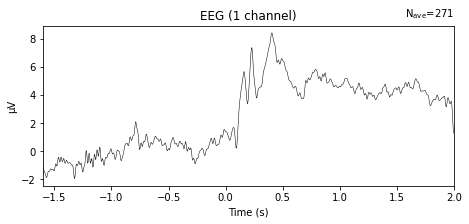

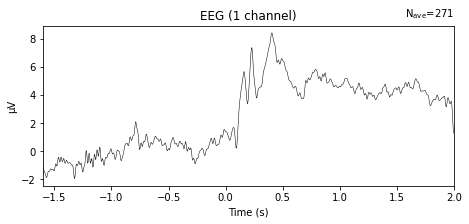

In [79]:
epochs_cleaned.average().plot(picks="Pz")

In [81]:
list_ti

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1.,
       0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0.,
       1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1.,
       0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 0., 1., 1., 1.

In [97]:
# %matplotlib qt 
events = epochs.events.copy()
events[:, 2] = np.where(list_ti == 1, 1, 2)

epochs_annoted = mne.EpochsArray(
    epochs.get_data(),
    epochs.info,
    events=events,
    tmin=epochs.tmin,
    event_id={'kept': 1, 'rejected': 2},
)

epochs_annoted.plot(events=True, event_color={1: 'blue', 2: 'red'})

Not setting metadata
336 matching events found
No baseline correction applied
0 projection items activated


In [ ]:
%%capture 

event_id_stim = { 
    'stim/motiv/extr':11,'stim/motiv/hard':12,'stim/motiv/easy':13,'stim/amotiv/extr':14,'stim/amotiv/hard':15,'stim/amotiv/easy':16
}

for i,part in enumerate(all_files_path[:20]): #only first 20 participants for the sake of practice

    raw = mne.io.read_raw_fif(part, preload=True)
    
    events = mne.find_events(raw, shortest_event=1)            

    epochs= mne.Epochs(raw, events,baseline = (-.3, -.1), event_id=event_id_stim, picks='eeg',
            tmin=-1.6, tmax=2,preload=True, detrend=None, on_missing='ignore')


    if i==0:  
        sphere = mne.make_sphere_model('auto', 'auto', epochs.info)
        src = mne.setup_volume_source_space(sphere=sphere)
        forward = mne.make_forward_solution(epochs.info, trans=None, src=src, bem=sphere)

    epochs.set_eeg_reference('REST', forward=forward)
    

    chs_index = [i for i,x in enumerate(epochs.info['ch_names']) if x in ['FCz','Pz']]
            # Combine channels into one average

    epochs_comb = mne.channels.combine_channels(epochs, dict(Avg=chs_index))
    _,list_ti,_,_,_ = drop_trials(epochs_comb, do_mean=1, do_peak=1, do_slope=1, T1=-.3,T2=.5, chs='all')  
    
    epochs.drop(list_ti==0)


    # Save the power data (time-frequency representation)
    epochs.crop(-.3,1.5), power.crop(-.3,1.5)

    conditions = ['motiv/extr', 'motiv/hard', 'motiv/easy', 'amotiv/extr', 'amotiv/hard', 'amotiv/easy']
    for cond in conditions:
        epochs[cond].average().save(part.split('raw')[0] + cond.replace("/", "-") + '_stim_full_ave.fif', overwrite=True)
        
